In [9]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [10]:
import pandas as pd
url = "data/nhanes_2015_2016.csv"
da = pd.read_csv(url)

In [11]:
gender = da['RIAGENDR']
gender.value_counts()

RIAGENDR
2    2976
1    2759
Name: count, dtype: int64

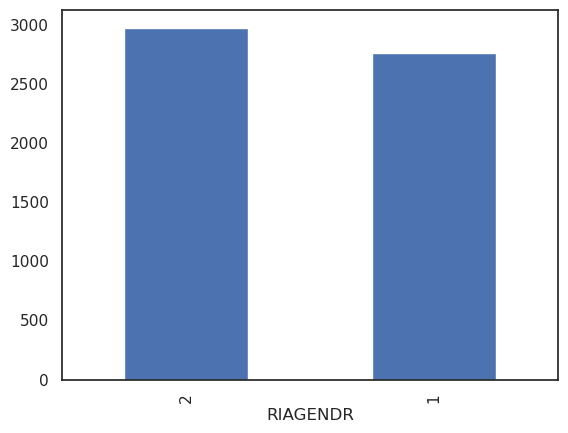

In [12]:
genValCnt = gender.value_counts()
genValCnt.plot(kind="bar")
plt.show()

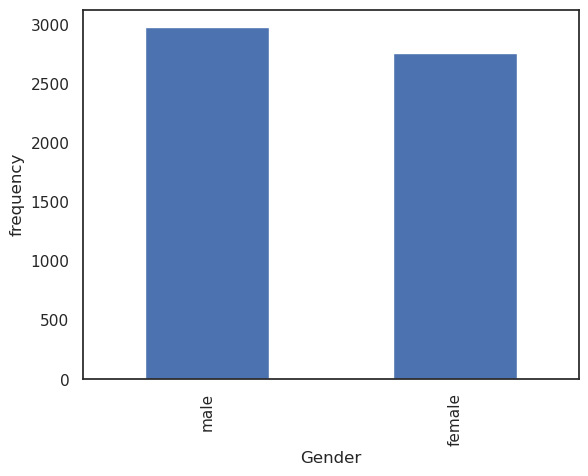

In [13]:
genValCnt.plot(kind="bar")
plt.xticks([0, 1], ['male', 'female'])
plt.xlabel('Gender')
plt.ylabel('frequency')
plt.show()

In [14]:
sizes = np.array([22, 23, 24, 24, 26, 27, 28, 29, 35, 39, 40, 42, 42, 42, 42, 42,42, 42, 42, 45, 46, 51, 52, 55])

In [15]:
sizes.mean()

np.float64(37.583333333333336)

In [16]:
from collections import Counter
cnt = Counter()
for size in sizes:
    cnt[size] += 1

In [17]:
cnt.most_common()         # index 0 is the most common i.e. the node

[(np.int64(42), 8),
 (np.int64(24), 2),
 (np.int64(22), 1),
 (np.int64(23), 1),
 (np.int64(26), 1),
 (np.int64(27), 1),
 (np.int64(28), 1),
 (np.int64(29), 1),
 (np.int64(35), 1),
 (np.int64(39), 1),
 (np.int64(40), 1),
 (np.int64(45), 1),
 (np.int64(46), 1),
 (np.int64(51), 1),
 (np.int64(52), 1),
 (np.int64(55), 1)]

In [18]:
!pip install scipy

In [19]:
from scipy import stats
stats.mode(sizes)

ModeResult(mode=np.int64(42), count=np.int64(8))

In [20]:
gender.mode()

0    2
Name: RIAGENDR, dtype: int64

In [21]:
stats.mode(gender)

ModeResult(mode=np.int64(2), count=np.int64(2976))

# more than one "classes"

In [22]:
da['HIQ210'].unique()

array([ 2., nan,  1.,  9.])

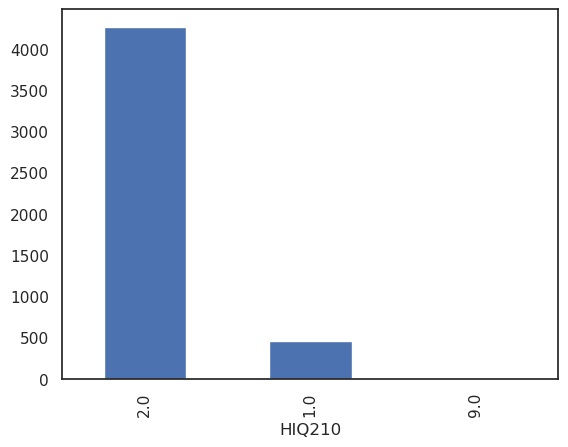

In [23]:
da['HIQ210'].value_counts().plot(kind='bar')
plt.show()

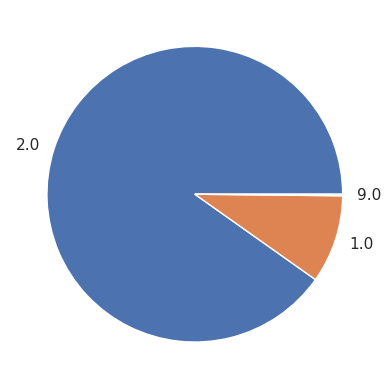

In [24]:
da['HIQ210'].value_counts().plot(kind='pie')         # highly not recommmended
plt.show()

# studying real valued numbers

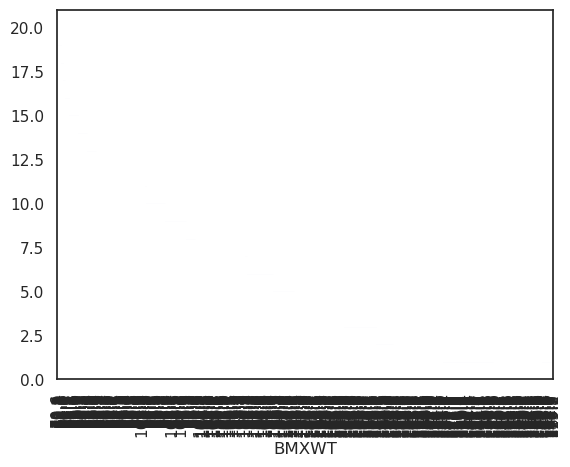

In [25]:
wt = da['BMXWT']
wt.value_counts().plot(kind='bar')       # this does not work at all
plt.show()

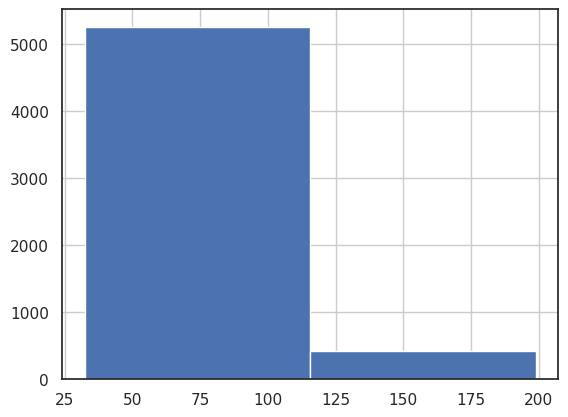

In [26]:
wt.hist(bins=2)
plt.show()

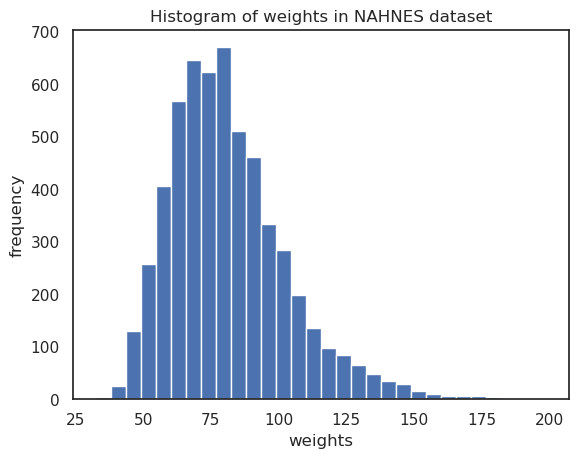

In [27]:
# custom matplotlib histogram
plt.hist(wt, bins=30)
plt.xlabel('weights')
plt.ylabel('frequency')
plt.title('Histogram of weights in NAHNES dataset')
plt.show()

In [28]:
!pip install seaborn

In [29]:
import seaborn as sns
sns.set(color_codes=True)
sns.set_style('white')

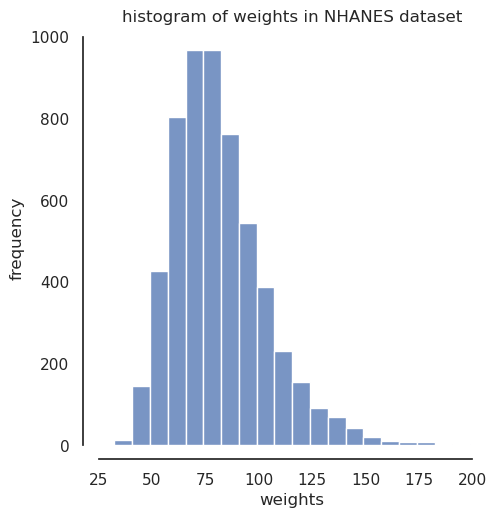

In [30]:
sns.displot(wt, bins=20)
plt.ylabel('frequency')
plt.xlabel('weights')
plt.title('histogram of weights in NHANES dataset')
sns.despine(offset=10, trim=True)        # move axes away
plt.show()

# lecture five: central tendency, median, quartiles, boxplots

## studying central tendency

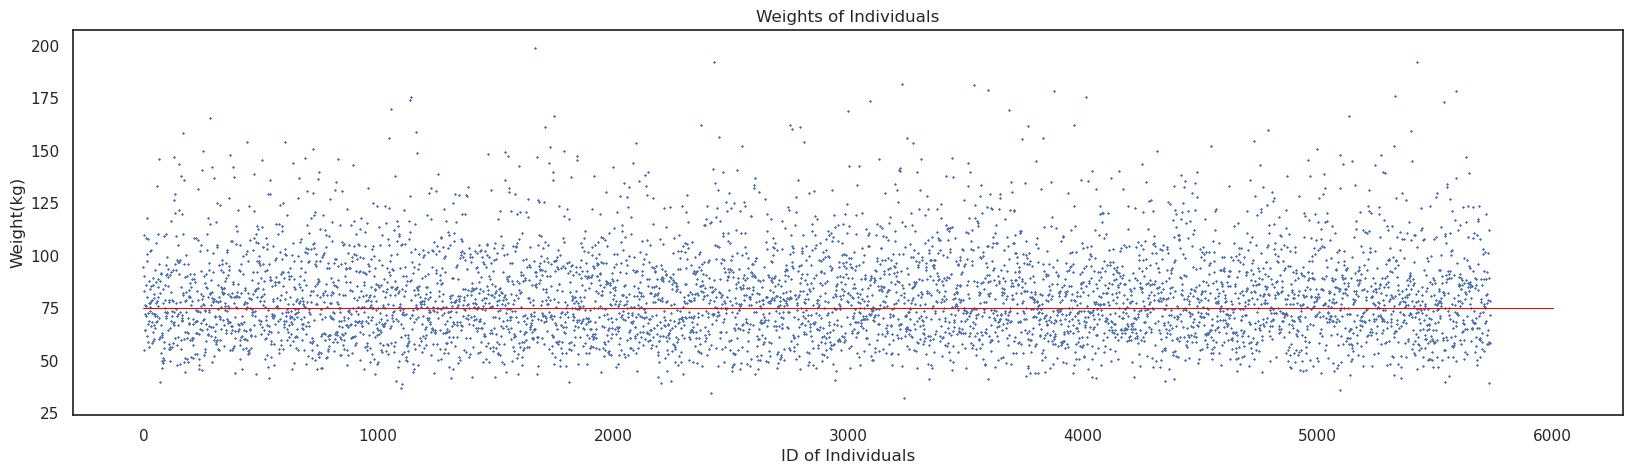

In [31]:
plt.figure(figsize=(20, 5))
x = range(da['BMXWT'].size)
y = da['BMXWT']
plt.scatter(x, y, marker='x', s=0.5)
plt.title('Weights of Individuals')
plt.xlabel('ID of Individuals')
plt.ylabel('Weight(kg)')
# plot the estimate line
p1 = (0, 75)
p2 = (6000, 75)
x_c, y_c = zip(p1, p2)
plt.plot(x_c, y_c, color='red', linewidth=0.75)
plt.show()

In [32]:
wt.mean()

np.float64(81.34267560889516)

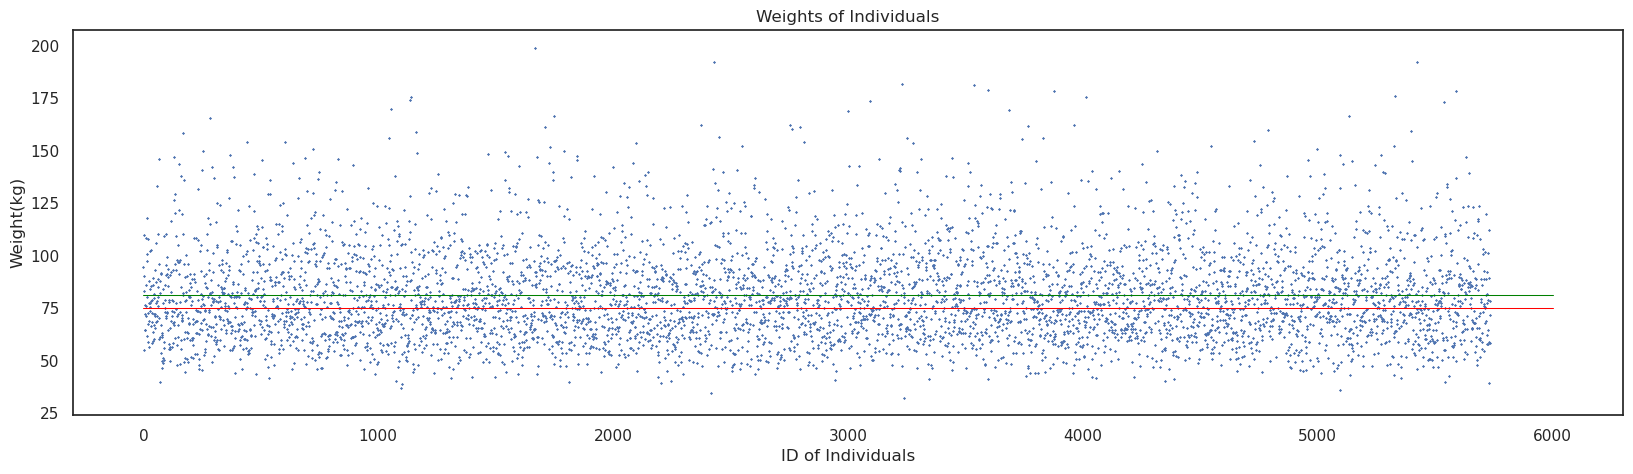

In [33]:
plt.figure(figsize=(20, 5))
x = range(da['BMXWT'].size)
y = da['BMXWT']
plt.scatter(x, y, marker='x', s=0.5)
plt.title('Weights of Individuals')
plt.xlabel('ID of Individuals')
plt.ylabel('Weight(kg)')

#plot the estimate line (estimate mean)
x_c, y_c = ([0, 6000], [75, 75])
plt.plot(x_c, y_c, color='red', linewidth=0.75)

# plot the estimate line (actual mean)
x_c, y_c = ([0, 6000], [wt.mean(), wt.mean()])
plt.plot(x_c, y_c, color='green', linewidth=0.75)

plt.show()

## problem with arithmetic mean

In [34]:
import numpy as np

In [35]:
nums = np.array([3, 4, 9, 17, 18, 20, 22, 23, 29, 32, 39, 42, 42, 42, 51, 97])

In [36]:
np.mean(nums)

np.float64(30.625)

In [37]:
# what happens if we change the value 97 to 197, 30.625 mean will jump to the 36.625, 
# jumps 6 points, this type of values is called outliers which pollutes our data.
nums = np.array([3, 4, 9, 17, 18, 20, 22, 23, 29, 32, 39, 42, 42, 42, 51, 197])
np.mean(nums)

np.float64(36.875)

In [38]:
# now we have to come up with a method to find out ouliers from thousands of values.

In [39]:
# side note: 

In [40]:
# median is a method which does not take effect from outliers which means "medians are robust to outliers".
# arithmetic mean is not "robust to outliers".
# robust is a technical term in stats. def of robust: that your outliers and unforseen 
# circumstances cannot adversly affect your analysis.

In [41]:
# let's try to do a different kind of average: the median!

## visualizing weights data
the problem with our weights data is similar

In [42]:
wt.max()

np.float64(198.9)

In [43]:
wt.min()

np.float64(32.4)

In [44]:
wt.median()

np.float64(78.2)

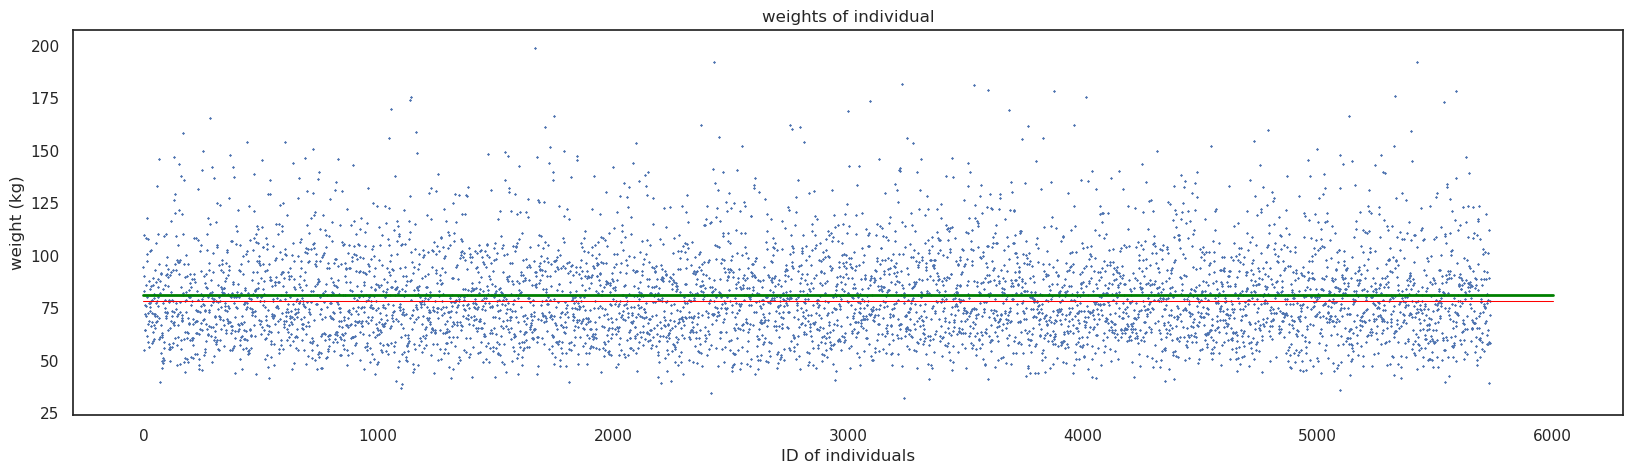

In [45]:
plt.figure(figsize=(20, 5))

x = range(da['BMXWT'].size)
y = da['BMXWT']

plt.scatter(x, y, marker='x', s=0.5)

plt.title('weights of individual')
plt.xlabel('ID of individuals')
plt.ylabel('weight (kg)')

# plot the estimate line (actual mean)
x_c, y_c = ([0, 6000], [wt.median(), wt.median()])
plt.plot(x_c, y_c, color='red', linewidth=0.75)

# plot the estimate line (actual mean)
x_c, y_c = ([0, 6000], [wt.mean(), wt.mean()])
plt.plot(x_c, y_c, color='green', linewidth=2)

plt.show()

## quartiles and boxplots

In [46]:
nums = np.array([3, 4, 9, 17, 18, 20, 22, 23, 29, 32, 39, 42, 42, 42, 51, 97])

In [47]:
np.median(nums)

np.float64(26.0)

In [48]:
import statistics

In [49]:
statistics.quantiles(nums, n=4)

[np.float64(17.25), np.float64(26.0), np.float64(42.0)]

In [50]:
statistics.quantiles(wt, n=4)

[43.7, 50.8, 50.1]

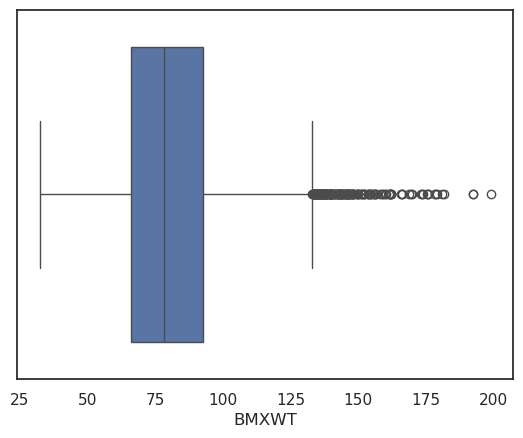

In [51]:
ax = sns.boxplot(x=wt)

In [52]:
male_wt = da.loc[da['RIAGENDR'] == 2, 'BMXWT']
male_wt.mean()            # try .mean()

np.float64(76.51676280963693)

In [53]:
female_wt = da.loc[da['RIAGENDR'] == 1, 'BMXWT']
female_wt.mean()            # try .mean()

np.float64(86.57326222876058)

/tmp/ipykernel_7220/635562989.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='RIAGENDR', y='BMXWT', data=da, palette='Set3')


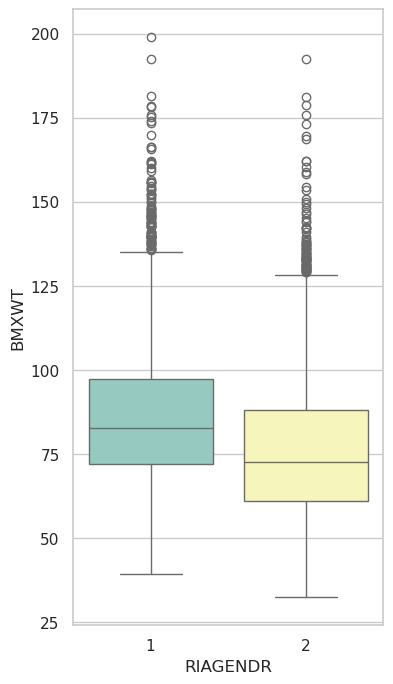

In [54]:
# bit there's an easier way
plt.figure(figsize=(4, 8))
sns.set_style('whitegrid')

ax = sns.boxplot(x='RIAGENDR', y='BMXWT', data=da, palette='Set3')

/tmp/ipykernel_7220/1141149045.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='HIQ210', y='BMXWT', data=da, palette='Set3')


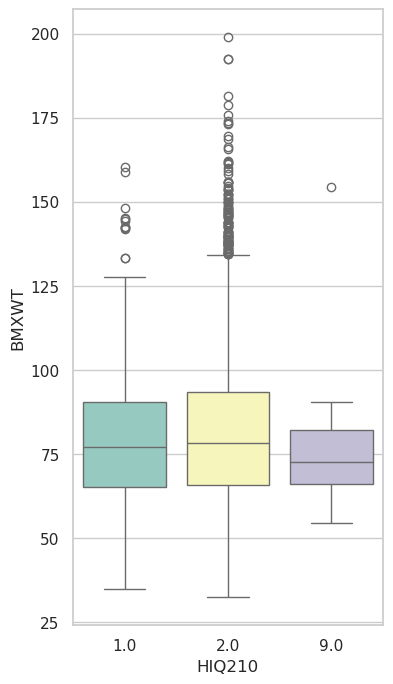

In [55]:
# bit there's an easier way
plt.figure(figsize=(4, 8))
sns.set_style('whitegrid')

ax = sns.boxplot(x='HIQ210', y='BMXWT', data=da, palette='Set3')

# Dispersion

In [56]:
import matplotlib 
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np 

In [57]:
import seaborn as sns
sns.set(color_codes=True)
sns.set_style("white")     # See more styling options here: https://seaborn.pydata.org/tutorial/aesthetics.html

In [58]:
np.random.uniform(low=0.0, high=1.0)      

0.6814167478197779

In [59]:
np.random.uniform(low=0.0, high=1.0, size = 10)
# All values equally likely. Sort of like     [  0.0   0.2   0.4    0.6    0.8   1.0 ]

array([0.34428925, 0.68598311, 0.12264825, 0.5019638 , 0.83352158,
       0.72515956, 0.6955231 , 0.17320316, 0.16615977, 0.14696701])

## Generating a LOT of numbers

In [72]:
num_samples = 10000            # get rid of magic numbers

In [73]:
uniform_vals = np.random.uniform(low=0.0, high=10.0, size=num_samples)

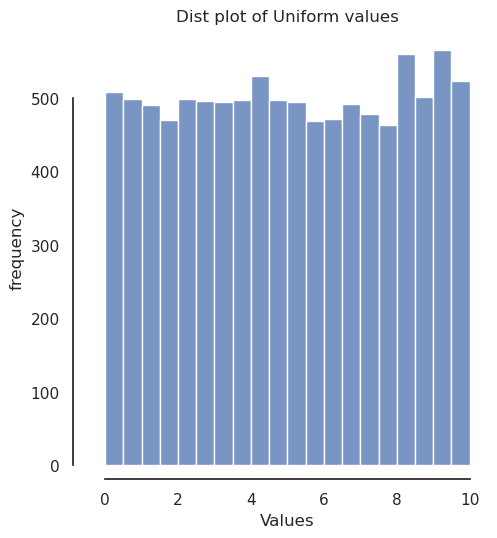

In [74]:
sns.displot(uniform_vals, bins=20, kde=False)
plt.title('Dist plot of Uniform values')
plt.xlabel('Values')
plt.ylabel('frequency')
sns.despine(offset=10, trim=True)
plt.show()

In [66]:
normal_vals = np.random.normal(loc=5.0, scale=10.0, size=num_samples)

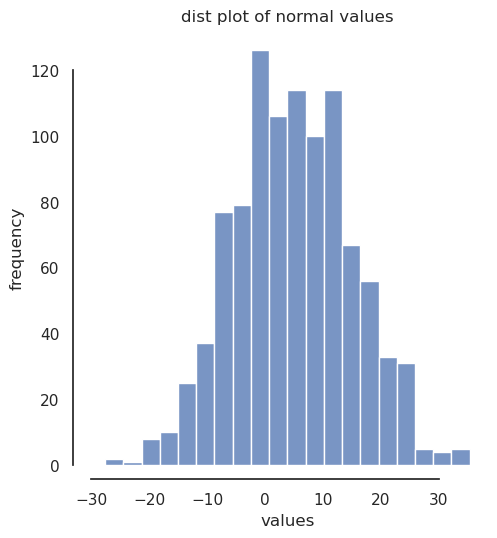

In [67]:
sns.displot(normal_vals, bins=20, kde=False)
plt.title('dist plot of normal values')
plt.xlabel('values')
plt.ylabel('frequency')
sns.despine(offset=10, trim=True)
plt.show()

In [75]:
print('Uniform values mean: ', np.mean(uniform_vals))
print('Normal values mean: ', np.mean(normal_vals))

Uniform values mean:  5.045796399752647
Normal values mean:  5.002386373413894


In [76]:
print("Uniform vals variance:", np.var(uniform_vals))
print("Normal vals variance: ", np.var(normal_vals))

Uniform vals variance: 8.483075099066328
Normal vals variance:  96.84566452748582


In [77]:
print("Uniform vals sd:", np.std(uniform_vals))
print("Normal vals sd: ", np.std(normal_vals))

Uniform vals sd: 2.9125719045315135
Normal vals sd:  9.841019486185658


In [78]:
normal_vals = np.random.normal(loc=5.0, scale=10.0, size = num_samples)

nv_mean = np.mean(normal_vals)
nv_sd = np.std(normal_vals)

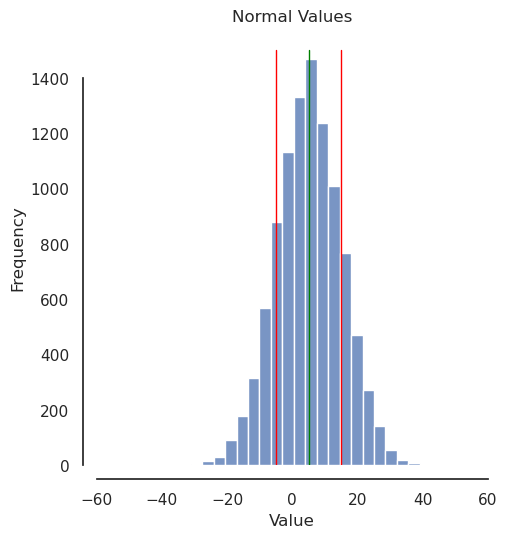

In [82]:
sns.displot(normal_vals, bins=20, kde=False)
plt.xlim(-60, 60)

plt.ylabel('Frequency')
plt.xlabel('Value');
plt.title("Normal Values")
sns.despine(offset=10, trim=True);  # move axes away 

# plot the SD line 
x_c, y_c = ([nv_mean, nv_mean], [0, 1500])
plt.plot(x_c, y_c, color='green', linewidth=1)

x_c, y_c = ([nv_mean + nv_sd, nv_mean + nv_sd], [0, 1500])
plt.plot(x_c, y_c, color='red', linewidth=1)


x_c, y_c = ([nv_mean - nv_sd, nv_mean - nv_sd], [0, 1500])
plt.plot(x_c, y_c, color='red', linewidth=1)

plt.show()

In [80]:
normal_vals_2 = np.random.normal(loc=5.0, scale=15.0, size = num_samples)
nv_mean_2 = np.mean(normal_vals_2)
nv_sd_2 = np.std(normal_vals_2)

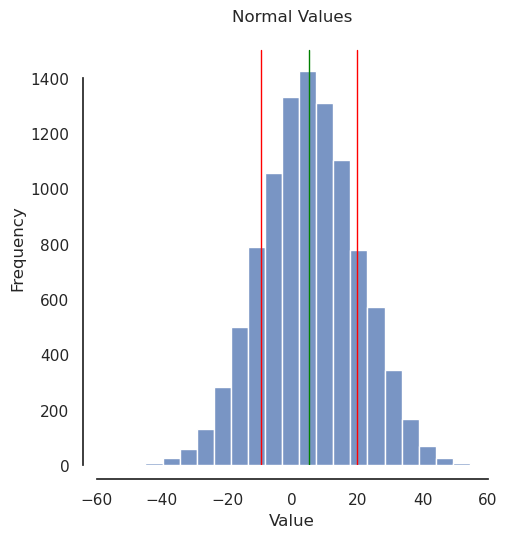

In [83]:
sns.displot(normal_vals_2, bins=20, kde=False)
plt.xlim(-60, 60)

plt.ylabel('Frequency')
plt.xlabel('Value');
plt.title("Normal Values")
sns.despine(offset=10, trim=True);  # move axes away 

# plot the SD line 
x_c, y_c = ([nv_mean_2, nv_mean_2], [0, 1500])
plt.plot(x_c, y_c, color='green', linewidth=1)

x_c, y_c = ([nv_mean_2 + nv_sd_2, nv_mean_2 + nv_sd_2], [0, 1500])
plt.plot(x_c, y_c, color='red', linewidth=1)


x_c, y_c = ([nv_mean_2 - nv_sd_2, nv_mean_2 - nv_sd_2], [0, 1500])
plt.plot(x_c, y_c, color='red', linewidth=1)

plt.show()

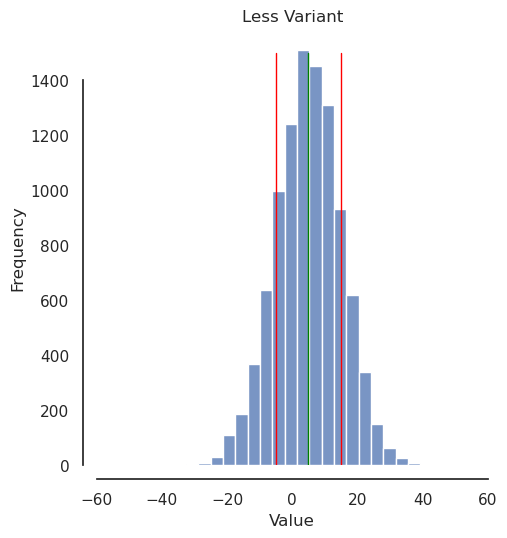

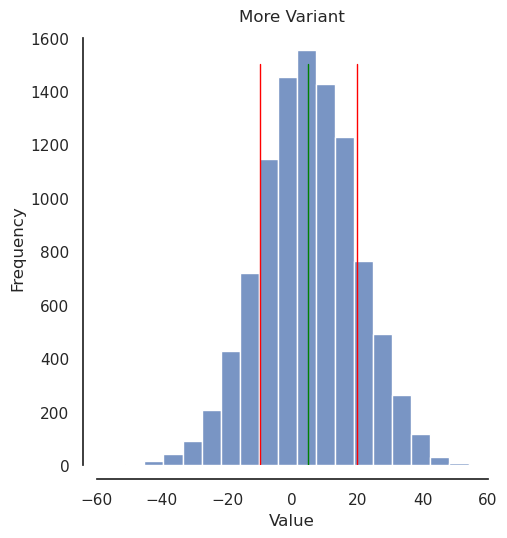

In [84]:
# Let's put both together
normal_vals = np.random.normal(loc=5.0, scale=10.0, size = num_samples)
normal_vals_2 = np.random.normal(loc=5.0, scale=15.0, size = num_samples)

def plot_dist(vals, label): 
    nv_mean = np.mean(vals)
    nv_sd = np.std(vals)
    
    sns.displot(vals, bins=20, kde=False)
    
    plt.xlim(-60, 60)

    plt.ylabel('Frequency')
    plt.xlabel('Value');
    plt.title(label)
    sns.despine(offset=10, trim=True);  # move axes away 

    # plot the SD line 
    x_c, y_c = ([nv_mean, nv_mean], [0, 1500])
    plt.plot(x_c, y_c, color='green', linewidth=1)

    x_c, y_c = ([nv_mean + nv_sd, nv_mean + nv_sd], [0, 1500])
    plt.plot(x_c, y_c, color='red', linewidth=1)


    x_c, y_c = ([nv_mean - nv_sd, nv_mean - nv_sd], [0, 1500])
    plt.plot(x_c, y_c, color='red', linewidth=1)

    plt.show()


    
plot_dist(normal_vals, "Less Variant")
plot_dist(normal_vals_2, "More Variant")


## Working with Real World Datasets 

In [85]:
!pip install scikit-learn

In [86]:
import sklearn
import numpy as np

In [87]:
from sklearn.datasets import fetch_california_housing

In [88]:
houses = fetch_california_housing()

In [89]:
print(houses.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [90]:
houses.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [91]:
houses.data.shape

(20640, 8)

In [92]:
houses.data[0]

array([   8.3252    ,   41.        ,    6.98412698,    1.02380952,
        322.        ,    2.55555556,   37.88      , -122.23      ])

In [93]:
houses.data[:10]             # add .shape to see what happens

array([[ 8.32520000e+00,  4.10000000e+01,  6.98412698e+00,
         1.02380952e+00,  3.22000000e+02,  2.55555556e+00,
         3.78800000e+01, -1.22230000e+02],
       [ 8.30140000e+00,  2.10000000e+01,  6.23813708e+00,
         9.71880492e-01,  2.40100000e+03,  2.10984183e+00,
         3.78600000e+01, -1.22220000e+02],
       [ 7.25740000e+00,  5.20000000e+01,  8.28813559e+00,
         1.07344633e+00,  4.96000000e+02,  2.80225989e+00,
         3.78500000e+01, -1.22240000e+02],
       [ 5.64310000e+00,  5.20000000e+01,  5.81735160e+00,
         1.07305936e+00,  5.58000000e+02,  2.54794521e+00,
         3.78500000e+01, -1.22250000e+02],
       [ 3.84620000e+00,  5.20000000e+01,  6.28185328e+00,
         1.08108108e+00,  5.65000000e+02,  2.18146718e+00,
         3.78500000e+01, -1.22250000e+02],
       [ 4.03680000e+00,  5.20000000e+01,  4.76165803e+00,
         1.10362694e+00,  4.13000000e+02,  2.13989637e+00,
         3.78500000e+01, -1.22250000e+02],
       [ 3.65910000e+00,  5.200000

In [94]:
houses.data[:10].shape

(10, 8)

In [95]:
[x for x in houses.data[:10]]

[array([   8.3252    ,   41.        ,    6.98412698,    1.02380952,
         322.        ,    2.55555556,   37.88      , -122.23      ]),
 array([ 8.30140000e+00,  2.10000000e+01,  6.23813708e+00,  9.71880492e-01,
         2.40100000e+03,  2.10984183e+00,  3.78600000e+01, -1.22220000e+02]),
 array([   7.2574    ,   52.        ,    8.28813559,    1.07344633,
         496.        ,    2.80225989,   37.85      , -122.24      ]),
 array([   5.6431    ,   52.        ,    5.8173516 ,    1.07305936,
         558.        ,    2.54794521,   37.85      , -122.25      ]),
 array([   3.8462    ,   52.        ,    6.28185328,    1.08108108,
         565.        ,    2.18146718,   37.85      , -122.25      ]),
 array([   4.0368    ,   52.        ,    4.76165803,    1.10362694,
         413.        ,    2.13989637,   37.85      , -122.25      ]),
 array([ 3.65910000e+00,  5.20000000e+01,  4.93190661e+00,  9.51361868e-01,
         1.09400000e+03,  2.12840467e+00,  3.78400000e+01, -1.22250000e+02]),
 a

In [98]:
med_incs = [x[0] for x in houses.data[:10]]

In [99]:
print(med_incs)

[np.float64(8.3252), np.float64(8.3014), np.float64(7.2574), np.float64(5.6431), np.float64(3.8462), np.float64(4.0368), np.float64(3.6591), np.float64(3.12), np.float64(2.0804), np.float64(3.6912)]


In [100]:
np.mean(med_incs)

np.float64(4.99608)

In [102]:
np.var(med_incs)

np.float64(4.5293918796)

In [103]:
np.std(med_incs)

np.float64(2.12823680064038)

In [104]:
# now finding mean and var for all the houses med_incs

In [107]:
med_incs = [x[0] for x in houses.data]

In [124]:
mean = np.mean(med_incs)
mean

np.float64(3.8706710029069766)

In [116]:
variance = np.var(med_incs)

In [125]:
sd = np.std(med_incs)
sd

np.float64(1.8997756945748738)

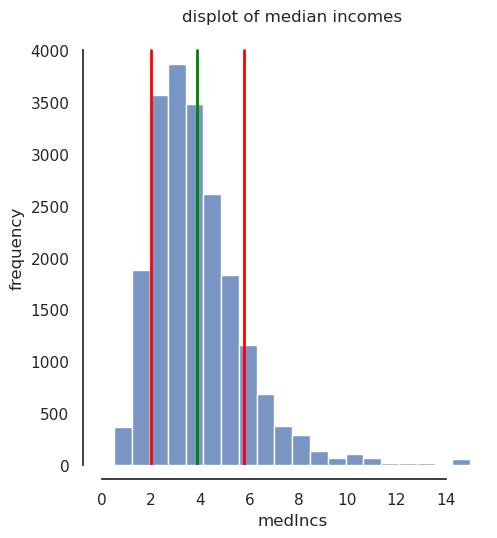

In [123]:
sns.displot(med_incs, bins=20, kde=False)
# plt.xlim(60, -60)

plt.title('displot of median incomes')
plt.xlabel('medIncs')
plt.ylabel('frequency')
sns.despine(offset=10, trim=True)

# plot the mean line
x_c, y_c = ([mean, mean], [0, 4000])
plt.plot(x_c, y_c, color='green', linewidth=2)

# plot the sd line to the right
x_c, y_c = ([mean+sd, mean+sd], [0, 4000])
plt.plot(x_c, y_c, color='red', linewidth=2)

# plot the sd line to the left
x_c, y_c = ([mean-sd, mean-sd], [0, 4000])
plt.plot(x_c, y_c, color='red', linewidth=2)

plt.show()